In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/baseline_clean.parquet")
df.shape


(2049280, 12)

In [35]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp,apparent_power,power_factor,frequency,thd
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,4.321056,0.975687,50.006094,2.914685
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,5.373490,0.997490,49.979200,3.349644
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,5.365670,1.000000,50.015009,3.881684
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,5.376020,1.000000,50.018811,3.766566
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,3.723744,0.984493,49.960979,4.403303


## Baseline signal behavior

### Voltage over time
Voltage stays within a tight band (~230–250V) over the sampled ~36-hour
window, with smooth drift rather than sudden jumps. This confirms the
grid keeps voltage well-regulated under normal conditions — an important
reference point, since later we'll inject anomalies (sags/swells) that
should look clearly different from this baseline.

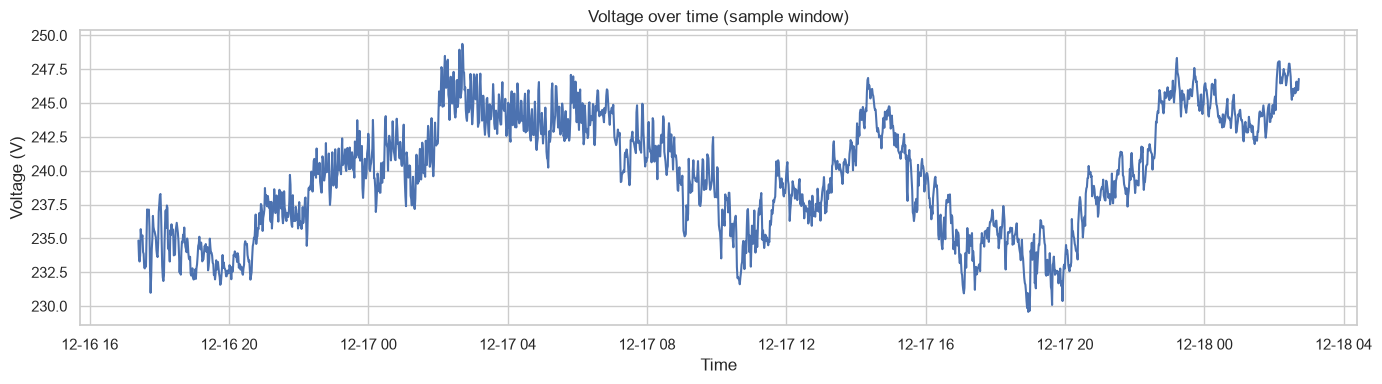

In [36]:
sample = df.iloc[:2000]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["timestamp"], sample["Voltage"])
ax.set_title("Voltage over time (sample window)")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage (V)")
plt.tight_layout()
plt.show()


### Active power over time
Active power is far more volatile than voltage, closely tracking
household appliance activity: rapid on/off cycling (likely a fridge or
heating element), sharp spikes (kettle, washing machine), and long quiet
stretches overnight near ~0.3 kW. This natural cyclical variability is
part of "normal" behavior our detector needs to learn — not every spike
in active power is an anomaly.

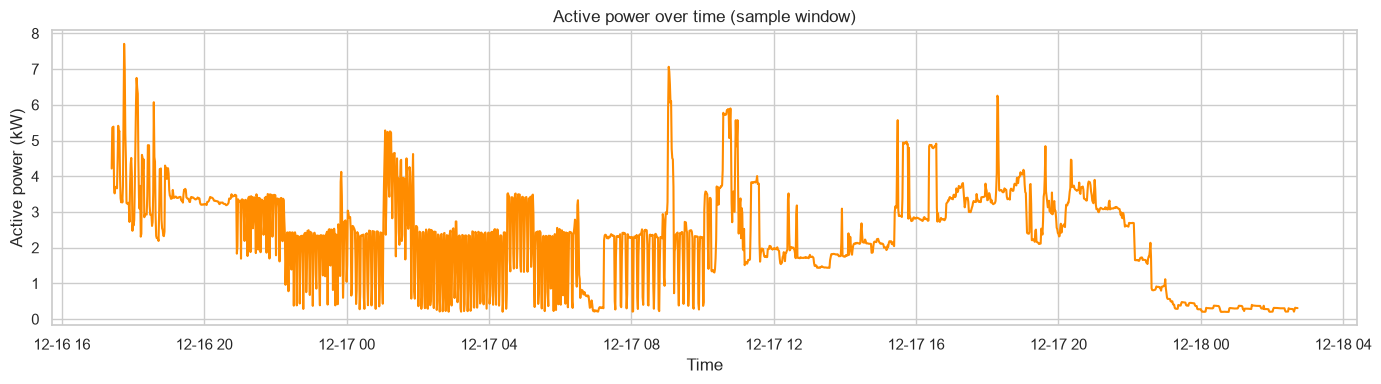

In [37]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["timestamp"], sample["Global_active_power"], color="darkorange")
ax.set_title("Active power over time (sample window)")
ax.set_xlabel("Time")
ax.set_ylabel("Active power (kW)")
plt.tight_layout()
plt.show()

### Signal distributions
- **Voltage**: roughly bell-shaped, centered around ~240V — consistent
  with the tight regulation seen in the time-series plot.
- **Active power / current**: right-skewed, with most readings low and
  a long tail of rarer high-usage periods — typical of household
  consumption patterns.
- **Power factor**: concentrated near 1.0 with a tail down to ~0.35,
  matching expectations — power factor drops during low-load periods
  when reactive power dominates relative to the small active power draw.

Together, these confirm the baseline dataset is clean and behaves
realistically, giving us a solid foundation to build synthetic anomalies
on top of in the next step.

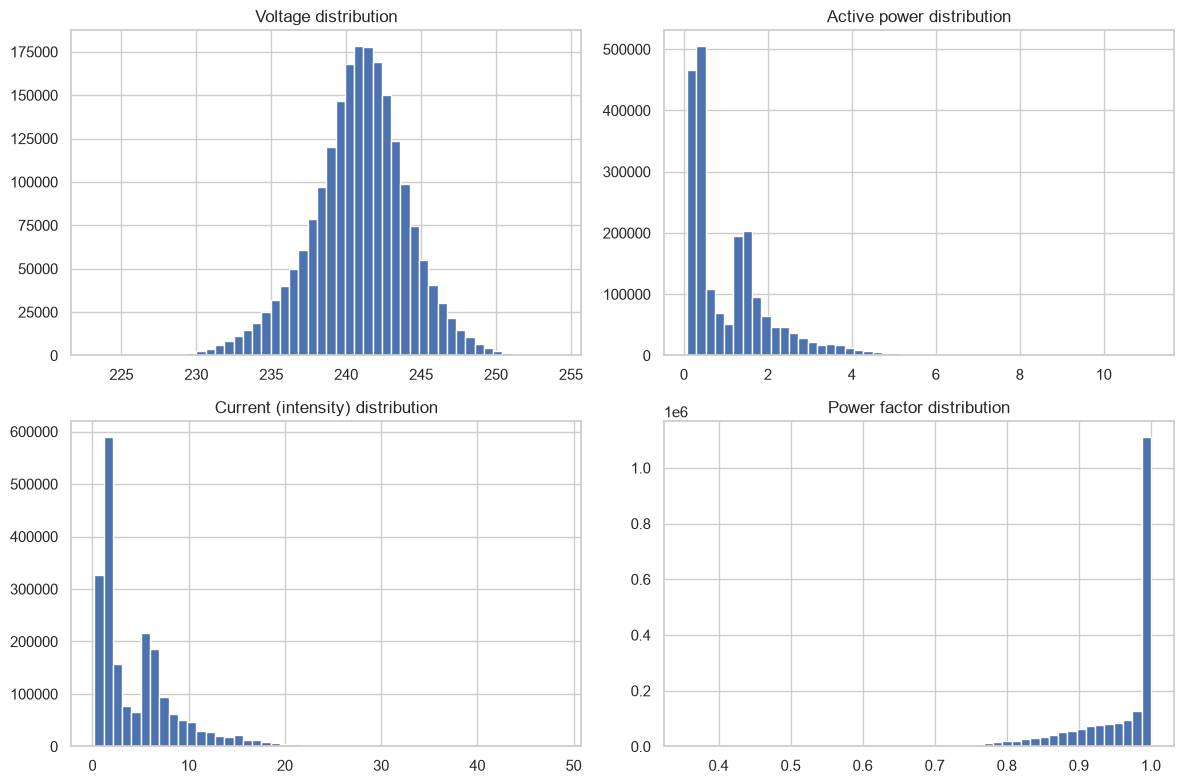

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df["Voltage"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Voltage distribution")

df["Global_active_power"].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Active power distribution")

df["Global_intensity"].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Current (intensity) distribution")

df["power_factor"].hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Power factor distribution")

plt.tight_layout()
plt.show()

## Verifying injected anomalies

Visual check of two injected anomaly types against their surrounding
normal data, to confirm the injection logic behaves as intended.

In [39]:
labeled = pd.read_parquet("../data/processed/labeled_data.parquet")

# Find the index ranges of one voltage_sag window and one too_clean window
sag_idx = labeled[labeled["anomaly_type"] == "voltage_sag"].index
clean_idx = labeled[labeled["anomaly_type"] == "too_clean"].index

# Take just the first contiguous window of each (they're randomly scattered
# across the dataset, so we group by consecutive index blocks)
def first_window(idx_array, pad=100):
    start = idx_array[0]
    end = start
    for i in idx_array[1:]:
        if i == end + 1:
            end = i
        else:
            break
    return max(0, start - pad), min(len(labeled), end + pad)

sag_start, sag_end = first_window(sag_idx)
clean_start, clean_end = first_window(clean_idx)

print(f"Voltage sag example window: rows {sag_start}-{sag_end}")
print(f"Too-clean example window: rows {clean_start}-{clean_end}")

Voltage sag example window: rows 30423-30674
Too-clean example window: rows 50908-51173


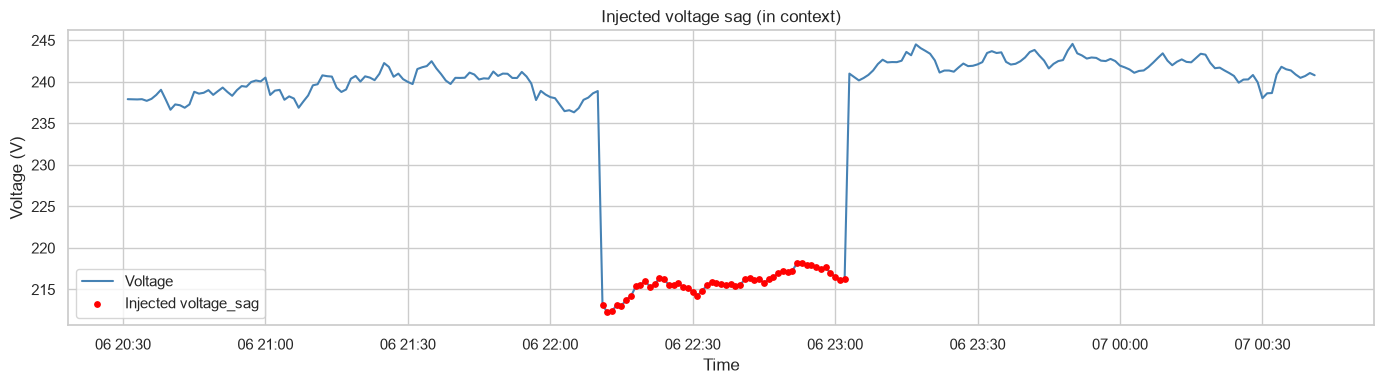

In [40]:
segment = labeled.iloc[sag_start:sag_end]

fig, ax = plt.subplots(figsize=(14, 4))
normal_mask = segment["anomaly_type"] == "none"
anomaly_mask = segment["anomaly_type"] == "voltage_sag"

ax.plot(segment["timestamp"], segment["Voltage"], color="steelblue", label="Voltage")
ax.scatter(segment.loc[anomaly_mask, "timestamp"], segment.loc[anomaly_mask, "Voltage"],
           color="red", s=15, label="Injected voltage_sag", zorder=5)
ax.set_title("Injected voltage sag (in context)")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage (V)")
ax.legend()
plt.tight_layout()
plt.show()

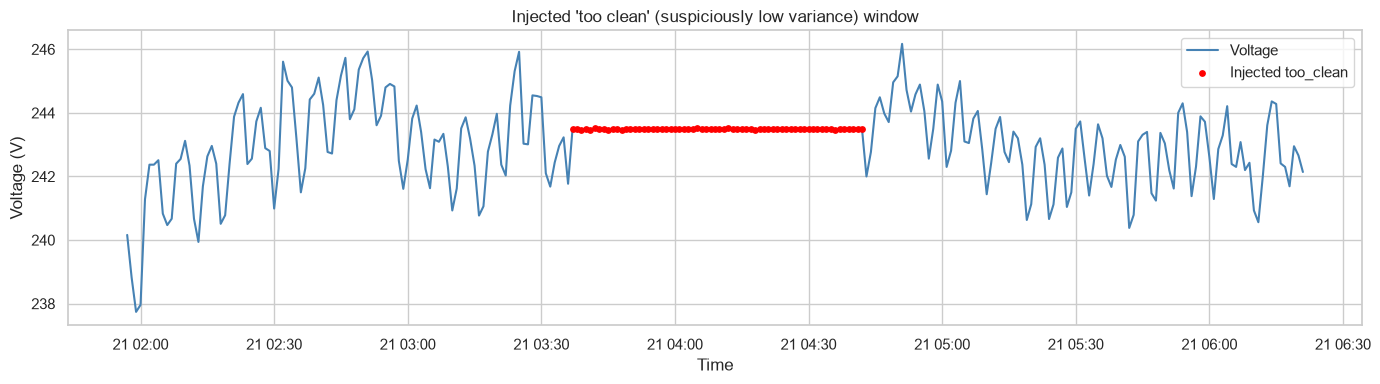

In [41]:
segment = labeled.iloc[clean_start:clean_end]

fig, ax = plt.subplots(figsize=(14, 4))
anomaly_mask = segment["anomaly_type"] == "too_clean"

ax.plot(segment["timestamp"], segment["Voltage"], color="steelblue", label="Voltage")
ax.scatter(segment.loc[anomaly_mask, "timestamp"], segment.loc[anomaly_mask, "Voltage"],
           color="red", s=15, label="Injected too_clean", zorder=5)
ax.set_title("Injected 'too clean' (suspiciously low variance) window")
ax.set_xlabel("Time")
ax.set_ylabel("Voltage (V)")
ax.legend()
plt.tight_layout()
plt.show()

## Detector agreement and escalation distribution

Now that the full pipeline is built, we can look at how the three
detectors agree with each other, and how the escalation logic routes
flagged anomalies across the whole dataset.

In [42]:
import joblib

labeled = pd.read_parquet("../data/processed/labeled_data.parquet")

iso_forest = joblib.load("../models/isolation_forest.joblib")
explainer_clf = joblib.load("../models/explainer_classifier.joblib")

FEATURES_DETECTOR = [
    "Voltage", "Global_active_power", "Global_reactive_power",
    "Global_intensity", "power_factor", "frequency", "thd",
]

# Isolation Forest predictions (row-level)
labeled["if_flag"] = iso_forest.predict(labeled[FEATURES_DETECTOR]) == -1

# Statistical detector flags (recompute, same logic as statistical_detector.py)
labeled["rolling_std"] = labeled["Voltage"].rolling(15, min_periods=15).std()
labeled["rate_of_change"] = labeled["Voltage"].diff().abs()
normal_mask = labeled["label"] == "normal"
std_thresh = labeled.loc[normal_mask, "rolling_std"].quantile(0.01)
roc_thresh = labeled.loc[normal_mask, "rate_of_change"].quantile(0.99)
labeled["stat_flag"] = (labeled["rolling_std"] < std_thresh) | (labeled["rate_of_change"] > roc_thresh)

print("Loaded models and recomputed row-level detector flags.")

Loaded models and recomputed row-level detector flags.


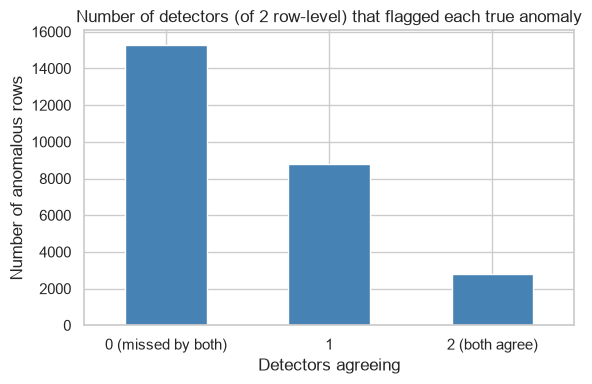

In [43]:
anomalous = labeled[labeled["label"] != "normal"].copy()
anomalous = anomalous.dropna(subset=["rolling_std"])

anomalous["n_detectors_agree"] = anomalous[["if_flag", "stat_flag"]].sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
anomalous["n_detectors_agree"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of detectors (of 2 row-level) that flagged each true anomaly")
ax.set_xlabel("Detectors agreeing")
ax.set_ylabel("Number of anomalous rows")
ax.set_xticklabels(["0 (missed by both)", "1", "2 (both agree)"], rotation=0)
plt.tight_layout()
plt.show()

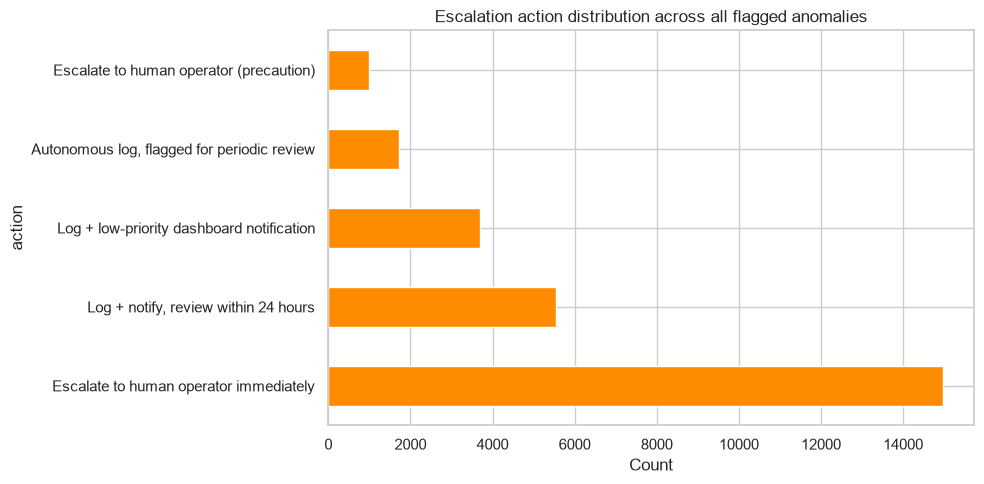

action
Escalate to human operator immediately         14977
Log + notify, review within 24 hours            5550
Log + low-priority dashboard notification       3690
Autonomous log, flagged for periodic review     1715
Escalate to human operator (precaution)          983
Name: count, dtype: int64


In [45]:
import sys
sys.path.append("..")  # so we can import from src/
import importlib
from src.escalation import escalation_logic
importlib.reload(escalation_logic)
from src.escalation.escalation_logic import decide_action, get_impact

DISCRIM_FEATURES = ["physical_inconsistency", "rolling_std", "outage_flag", "rate_of_change"]

expected_power = (anomalous["Voltage"] * anomalous["Global_intensity"] * anomalous["power_factor"] / 1000)
denom = expected_power.abs().clip(lower=0.05)
anomalous["physical_inconsistency"] = (anomalous["Global_active_power"] - expected_power).abs() / denom
anomalous["outage_flag"] = (
    (anomalous["Voltage"] < 1.0) & (anomalous["Global_active_power"] < 1.0) & (anomalous["Global_intensity"] < 1.0)
).astype(int)

X = anomalous[DISCRIM_FEATURES].fillna(0)
anomalous["predicted_verdict"] = explainer_clf.predict(X)
anomalous["confidence"] = explainer_clf.predict_proba(X).max(axis=1)

anomalous["action"] = anomalous.apply(
    lambda row: decide_action(row["confidence"], row["anomaly_type"]).value, axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))
anomalous["action"].value_counts().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Escalation action distribution across all flagged anomalies")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

print(anomalous["action"].value_counts())